# Reinforcement Learning: DQN and Policy Gradients

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Understand **reinforcement learning** (agent, environment, reward, policy)
- Run a **simple environment** (e.g. CartPole from Gym) and see random vs a few steps of learning
- See the idea of **Q-learning** / **policy gradients** (we use RL instead of supervised learning when we have rewards, not labels)

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — states, actions and rewards with the transition model handed to you; here a network learns without one.

**Used later in:** Course 09 (AIAT 123) — Unit 3, lesson 01 "DQN Implementation" — the full treatment, with replay buffers and target networks.

---

## 🌍 Real life

**📌 Real case — 49 games, one algorithm, and the one it could not play.** Mnih et al. (*Nature* 518, 529-533, 2015) trained a deep Q-network on 49 Atari 2600 titles, receiving nothing but the raw pixels and the score, and reached a level "comparable to that of a professional human games tester". The claim is about the *recipe*, not one set of weights: the Methods section says "a different network was trained on each game: **the same network architecture, learning algorithm and hyperparameter settings** ... were used across all games". The same paper is honest about the limit in the same breath: games "demanding more temporally extended planning strategies still constitute a major challenge for all existing agents including DQN (for example, Montezuma's Revenge)". Learn both halves of that sentence — the second half is the more useful one.

**⚡ Why this matters — what goes wrong without it.** Supervised learning needs somebody to write down the right answer. For balancing a pole, routing a delivery fleet, or scheduling machines, nobody can: the right action depends on a future that has not happened yet, and the consequence of a move arrives many steps later. Reinforcement learning replaces the label with a reward and lets the agent discover the mapping. Our run is that in miniature — random actions keep the pole up for **18 steps** in the seeded episode below, **21 steps** on average over twenty; over a 500-episode REINFORCE run driven by nothing but the reward signal, the 20-episode average logged at episode 450 reaches **479**, and then slides back to **349** across the final twenty episodes. Both halves of that sentence are the lesson.

**Where is this used?** RL is used in **games**, **robotics**, **recommendation**, and **autonomous driving** when we have **rewards** (or penalties) instead of labeled data.

**In this notebook we use** an **RL environment** (e.g. CartPole) and take **random actions** (or a simple policy) to see how reward accumulates. We use **reinforcement learning** (instead of supervised learning) **because** we don't have "correct" actions; we have **rewards** and the agent learns by trial and error.

**📌 Covers slide(s):** **18** — Reinforcement Learning (DQN, policy gradients). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell. Install **gymnasium** if needed: `pip install gymnasium` (required; old `gym` is not used here).


## Theory (short)

- **RL:** Agent takes **actions** in an **environment**; gets **rewards** (or penalties). Goal: maximize cumulative reward. No labeled (state, action) pairs; we learn from experience.
- **DQN:** Deep Q-Network; a neural network approximates Q(s, a) (expected return for state s, action a). We use **DQN** (instead of tabular Q-learning) when the state space is large or continuous.
- **Policy gradients:** Directly optimize a **policy** (probability of actions) using gradient ascent on expected return. Used in actor-critic, PPO, etc.
- **We use an environment** (e.g. CartPole) so you see state, action, reward in a few steps without full DQN training (which takes longer).

## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, optional `gym` or `gymnasium`. We use **CartPole** (balance a pole on a cart) so the notebook runs without extra setup.

**Dataset:** Real — CartPole (OpenAI Gym environment).

**Outputs:** Printed steps (state, action, reward, done) and the total reward of one random episode; a learning curve for 500 REINFORCE episodes drawn against the random baseline it has to beat; and a frame-by-frame storyboard of a random episode next to a trained one.

## Step 1: Imports and create environment (we use Gym/Gymnasium to get state–action–reward interface)

In [1]:
# WHAT: create the CartPole environment and inspect its action and observation spaces.
# WHY: the spaces (2 discrete actions, 4 continuous observations) define what any policy must map between.
import numpy as np

# gymnasium is the maintained fork of OpenAI Gym; the guarded import gives an install hint if missing.
try:
    import gymnasium as gym
    ENV_NAME = "CartPole-v1"
    HAS_GYM = True
except ImportError:
    HAS_GYM = False

if HAS_GYM:
    env = gym.make(ENV_NAME)
    print("Environment:", ENV_NAME)
    print("Action space:", env.action_space)
    print("Observation space:", env.observation_space)
else:
    print("Install gym: pip install gymnasium (or pip install gym)")

Environment: CartPole-v1
Action space: Discrete(2)
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


## Step 2: Run one episode with random actions (we use random policy to show how reward is collected; DQN would learn a better policy)

In [2]:
# WHAT: run one episode with completely random actions and total up the reward.
# WHY: random play is the baseline - any learning algorithm must beat this score to prove it learned.
if HAS_GYM:
    # Seed both the environment and the action sampler: without this the step count
    # below changes every run, and no number in this lesson could be quoted honestly.
    reset_result = env.reset(seed=0)
    env.action_space.seed(0)
    obs = reset_result[0] if isinstance(reset_result, tuple) else reset_result
    total_reward = 0
    # Step the environment up to 100 times; each step returns the new observation and a reward.
    for step in range(100):
        action = env.action_space.sample()
        result = env.step(action)
        # Handle both the old (4-tuple) and new (5-tuple) step APIs.
        if len(result) == 5:
            obs, reward, terminated, truncated, info = result
            done = terminated or truncated
        else:
            obs, reward, done, info = result
        total_reward += reward
        if done:
            break
    env.close()
    print("Steps:", step + 1, "Total reward:", total_reward)
    print("RL: agent learns to maximize total reward; DQN/policy gradients train a neural network policy.")

Steps: 18 Total reward: 18.0
RL: agent learns to maximize total reward; DQN/policy gradients train a neural network policy.


*(Optional)* For full DQN: add a Q-network, replay buffer, and train for many episodes.

In [3]:
# (No extra code; Step 2 above runs one episode. Uncomment and run again to see variance in total reward.)

## 🌍 Real-World Worked Example — REINFORCE on CartPole

**Industry context:**
- The RLHF stage behind ChatGPT uses a policy gradient variant — same core idea as REINFORCE. The InstructGPT paper, which ChatGPT's training followed, states: "we fine-tuned the SFT model on our environment using PPO" (Ouyang et al., 2022, [arXiv:2203.02155](https://arxiv.org/abs/2203.02155))
- DeepMind's DQN learned 49 Atari 2600 games from raw pixels and the score alone, reaching the level of a professional human games tester (Mnih et al., *Nature* 518, 2015)
- AlphaGo's networks were trained by "a novel combination of supervised learning from human expert games, and reinforcement learning from games of self-play" (Silver et al., *Nature* 529, 484-489, 2016)

We implement **REINFORCE** (the simplest policy gradient) on CartPole-v1.

Random-policy baseline over 20 episodes: mean 21.2 steps (worst 11, best 46)
Episode   0 | Avg reward: 13.0
Episode  50 | Avg reward: 30.4


Episode 100 | Avg reward: 40.2


Episode 150 | Avg reward: 96.9


Episode 200 | Avg reward: 155.2


Episode 250 | Avg reward: 89.7


Episode 300 | Avg reward: 159.4


Episode 350 | Avg reward: 212.4


Episode 400 | Avg reward: 188.9


Episode 450 | Avg reward: 479.1


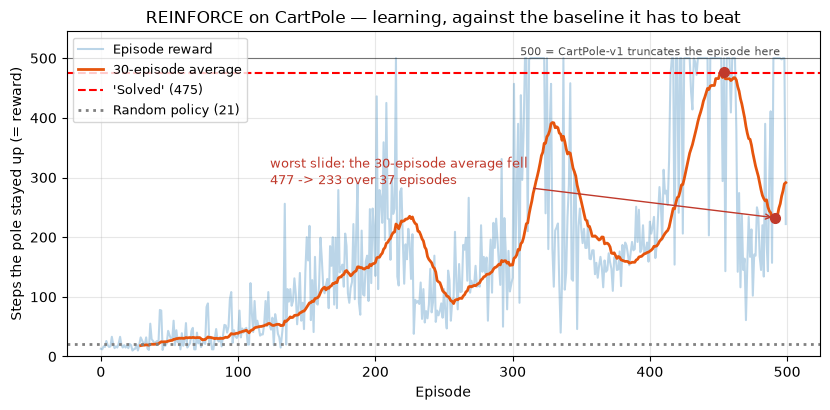

Last 20-episode average: 348.9  (random baseline 21.2)


In [4]:
# WHAT: train a policy network on CartPole with REINFORCE (policy gradients) for 500 episodes.
# WHY: instead of learning values, we directly increase the probability of actions that led to high reward.
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)
env = gym.make('CartPole-v1')

# The policy network: an observation (4 numbers) -> probabilities over the 2 actions.
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 128), nn.ReLU(),
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        )
    def forward(self, x): return self.net(x)

policy  = PolicyNet()
opt     = optim.Adam(policy.parameters(), lr=2e-3)
GAMMA   = 0.99; ep_rewards = []

# Baseline FIRST: 20 episodes of pure random actions. Any learning curve is meaningless
# without the line it has to beat, so we measure that line instead of asserting it.
env.reset(seed=0); env.action_space.seed(0)
random_scores = []
for _ in range(20):
    env.reset(); steps = 0; done = trunc = False
    while not (done or trunc):
        _, _, done, trunc, _ = env.step(env.action_space.sample()); steps += 1
    random_scores.append(steps)
random_baseline = float(np.mean(random_scores))
print(f"Random-policy baseline over 20 episodes: mean {random_baseline:.1f} steps "
      f"(worst {min(random_scores)}, best {max(random_scores)})")

# Play one episode, remembering each chosen action's log-probability and each reward.
for episode in range(500):
    # Seed only the first reset: gymnasium then continues one reproducible random stream,
    # so every episode is different but the whole run repeats exactly for the next student.
    obs,_ = env.reset(seed=42) if episode == 0 else env.reset()
    log_probs=[]; rewards_ep=[]
    for _ in range(500):
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        dist   = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, r, done, trunc, _ = env.step(action.item())
        rewards_ep.append(r)
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    G = 0; returns = []
    for r in reversed(rewards_ep):
        G = r + GAMMA*G; returns.insert(0, G)
    returns = torch.tensor(returns).float()
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    opt.zero_grad(); loss.backward(); opt.step()
    ep_rewards.append(sum(rewards_ep))
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

env.close()

# Learning curve: raw episodes, a 30-episode moving average plotted at the RIGHT x positions
# (a 30-wide window first has a value at episode 29), the random baseline it must beat, and
# the 'solved' line. Everything the curve is compared against is drawn on the same axis.
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
ma_x = np.arange(29, len(ep_rewards))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot(ep_rewards, alpha=0.3, label="Episode reward")
ax.plot(ma_x, ma, lw=2, color='#e6550d', label="30-episode average")
ax.axhline(475, color='red', linestyle='--', label="'Solved' (475)")
ax.axhline(random_baseline, color='grey', linestyle=':', lw=2,
           label=f"Random policy ({random_baseline:.0f})")
ax.axhline(500, color='black', linestyle='-', lw=0.8, alpha=0.5)
ax.text(len(ep_rewards) - 5, 505, "500 = CartPole-v1 truncates the episode here",
        fontsize=8, color='black', alpha=0.7, ha='right')

# Mark the worst sustained decline in the moving average (peak to following trough) - the
# variance REINFORCE is famous for, measured rather than asserted.
trough = int(np.argmax(np.maximum.accumulate(ma) - ma))
peak = int(np.argmax(ma[:trough + 1]))
ax.plot([ma_x[peak], ma_x[trough]], [ma[peak], ma[trough]], 'o', color='#c0392b', ms=7, zorder=5)
ax.annotate(f"worst slide: the 30-episode average fell\n"
            f"{ma[peak]:.0f} -> {ma[trough]:.0f} over {ma_x[trough] - ma_x[peak]} episodes",
            xy=(ma_x[trough], ma[trough]), xytext=(0.27, 0.53), textcoords='axes fraction',
            fontsize=9, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b'))
ax.set_xlabel("Episode"); ax.set_ylabel("Steps the pole stayed up (= reward)")
ax.set_ylim(0, 545)
ax.set_title("REINFORCE on CartPole — learning, against the baseline it has to beat")
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
print(f"Last 20-episode average: {np.mean(ep_rewards[-20:]):.1f}  "
      f"(random baseline {random_baseline:.1f})")

**Read the figure.** The pale line is every single episode, the orange line is the 30-episode average
plotted at the episodes it actually covers, and the two flat lines are what the curve must be read
against: the grey dotted line is what *random* actions score (21 steps), and the red dashed line is the
475 that counts as "solved". The black line at 500 is the ceiling — CartPole-v1 cuts every episode off
there, so no run can score more, and a 500 is a truncation, not a triumph.

Two things to take from it. First, the orange line climbs far clear of the grey one: the agent learned
from reward alone, with nobody ever telling it which action was correct. Second, **the climb is not
monotonic** — the two red dots and the arrow mark the worst slide, where the 30-episode average fell
from 477 to 233 in 37 episodes, and it happens at the *end* of the run. Stop training at episode 455
and you report a nearly-solved agent; stop at episode 492 and you report a mediocre one. That is
REINFORCE's high-variance gradient estimate, and it is why a single run's final number is not a result
you should quote without saying how many seeds you ran.

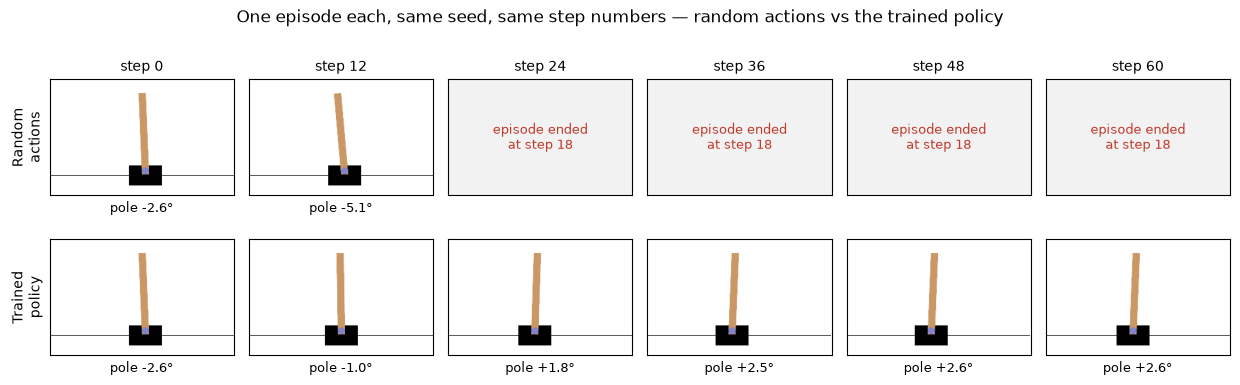

 step   random pole angle   trained pole angle
    0               -2.6°                -2.6°
   12               -5.1°                -1.0°
   24       (ended at 18)                +1.8°
   36       (ended at 18)                +2.5°
   48       (ended at 18)                +2.6°
   60       (ended at 18)                +2.6°

Random episode ended at step 18 with the pole at -13.2 degrees (CartPole-v1 stops the episode past 12 degrees).  Trained policy: still balancing after 60 rendered steps (we stopped recording, not the pole).


In [5]:
# WHAT: photograph two CartPole episodes - random actions vs the policy we just trained -
#       and lay the frames out side by side at the same step numbers.
# WHY: the learning curve says the agent improved; this shows you WHAT improved. The recording
#      idiom (step the env, grab an rgb_array frame before each action) is the same one used by
#      Course 09's course09_step_viz.collect_rollout_frames.
import numpy as np, matplotlib.pyplot as plt, torch, gymnasium as gym

MAX_STEPS = 60          # a storyboard, not a movie: 60 frames is under a second of rendering
ROWS = slice(150, 330)  # the render is mostly empty sky; keep the band with the cart and pole

def collect_rollout(policy_fn, max_steps=MAX_STEPS, seed=0):
    """Run one episode, keeping an rgb frame, the pole angle and the cart position each step."""
    env_v = gym.make("CartPole-v1", render_mode="rgb_array")
    obs, _ = env_v.reset(seed=seed)
    env_v.action_space.seed(seed)
    frames, angles, carts = [], [], []
    terminated = truncated = False
    steps = 0
    while not (terminated or truncated) and steps < max_steps:
        frames.append(np.asarray(env_v.render())[ROWS])
        angles.append(float(obs[2]))   # obs[2] = pole angle (radians)
        carts.append(float(obs[0]))    # obs[0] = cart position (metres)
        obs, _, terminated, truncated, _ = env_v.step(policy_fn(obs, env_v))
        steps += 1
    frames.append(np.asarray(env_v.render())[ROWS])
    angles.append(float(obs[2])); carts.append(float(obs[0]))
    env_v.close()
    return frames, np.degrees(angles), np.array(carts), (terminated or truncated)

# Random actions, then the trained policy taking its most probable action at each state.
rand_frames, rand_ang, rand_x, rand_done = collect_rollout(lambda o, e: e.action_space.sample())
def greedy(obs, env_v):
    with torch.no_grad():
        return int(policy(torch.tensor(obs).float().unsqueeze(0)).argmax())
pol_frames, pol_ang, pol_x, pol_done = collect_rollout(greedy)

# Zoom in horizontally, but on ONE window shared by both rows so the two are comparable.
# CartPole renders x in [-2.4, 2.4] metres across 600 pixels.
px = lambda x: 300 + x * (600 / 4.8)
lo = px(min(rand_x.min(), pol_x.min())) - 130
hi = px(max(rand_x.max(), pol_x.max())) + 130
x0, x1 = int(max(0, lo)), int(min(600, hi))
h, w = rand_frames[0][:, x0:x1].shape[:2]

COLS = [0, 12, 24, 36, 48, 60]
rows = [("Random\nactions", rand_frames, rand_ang), ("Trained\npolicy", pol_frames, pol_ang)]
fig, axes = plt.subplots(2, len(COLS), figsize=(12.5, 4.0))
for r, (label, frames, angles) in enumerate(rows):
    for c, step in enumerate(COLS):
        ax = axes[r, c]
        if step < len(frames):
            ax.imshow(frames[step][:, x0:x1])
            ax.set_xlabel(f"pole {angles[step]:+.1f}\u00b0", fontsize=9)
        else:
            # No frame exists because the episode was already over - say so instead of
            # repeating the last picture, which would imply the pole was still up.
            ax.text(w / 2, h / 2, f"episode ended\nat step {len(frames) - 1}", ha="center",
                    va="center", fontsize=9, color="#c0392b")
            ax.set_facecolor("#f2f2f2")
        # Same pixel window on every panel, so all twelve are the same size and scale.
        ax.set_xlim(0, w); ax.set_ylim(h, 0); ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(f"step {step}", fontsize=10)
    axes[r, 0].set_ylabel(label, fontsize=10)
fig.suptitle("One episode each, same seed, same step numbers — random actions vs the trained policy",
             fontsize=12)
fig.tight_layout(); plt.show()

# The step table behind the storyboard.
print(f"{'step':>5} {'random pole angle':>19} {'trained pole angle':>20}")
for step in COLS:
    a = f"{rand_ang[step]:+.1f}\u00b0" if step < len(rand_ang) else f"(ended at {len(rand_ang)-1})"
    b = f"{pol_ang[step]:+.1f}\u00b0" if step < len(pol_ang) else f"(ended at {len(pol_ang)-1})"
    print(f"{step:5d} {a:>19} {b:>20}")
print(f"\nRandom episode ended at step {len(rand_ang) - 1} with the pole at "
      f"{rand_ang[-1]:+.1f} degrees (CartPole-v1 stops the episode past 12 degrees)."
      f"  Trained policy: still balancing after {len(pol_ang) - 1} rendered steps"
      f"{' (episode ended)' if pol_done else ' (we stopped recording, not the pole)'}.")


**Read the storyboard.** Both rows start from the *same* initial state — step 0 is identical in both,
the pole 2.6° off vertical. Top row: random actions. By step 12 the tilt has grown to 5.1°, and the
episode is over at step 18; the four grey panels are not a rendering failure, there is simply no step 24
to show, because the pole passed the angle limit and the environment stopped. Bottom row: the trained
policy from the same start. The angle flips sign — the pole crosses the vertical — and then stays
between about 1° and 3° for every frame we recorded. We stopped the recording at step 60; the pole did
not fall.

That is what the learning curve above is a summary of. The curve says "the number got bigger"; this
says the agent learned to make small corrections before the pole gets away from it — and nobody ever
told it that. It only ever received +1 per step for still being upright.

## 💬 Discuss

1. Random actions score **21** on average; our trained policy's last twenty episodes average **349**, having peaked far higher. But CartPole-v1 truncates episodes at 500 steps. What does 349 actually mean, and what must you report alongside it so a reader is not misled into thinking the agent is 17× better than random at *something*?
2. One algorithm reached professional-human level across 49 Atari games and could not play Montezuma's Revenge at all. What property separates the games it solved from the one it did not — and which problem in your own future work has that property?
3. A factory asks you to use RL to schedule its machines. There is no simulator, and every bad schedule costs real money. What do you tell them, and what would you propose instead?


## ⚠️ Where this breaks

- **Sample cost is the binding constraint.** 500 episodes to balance a pole that has four state variables and two actions. A real robot cannot fall over 500 times, and each fall is not free. This is why RL is used where a fast, faithful simulator exists, and very rarely where one does not.
- **Variance — visible in our own curve.** Episode 200 averaged **155.2**; fifty episodes later it had *fallen* to **89.7**. Worse, the 30-episode average peaked at **477** near episode 455 and finished the run at **233** — the arrow on the learning curve marks that slide. REINFORCE's gradient estimate is high-variance; stop the run at the wrong episode and you report a different agent. We seed this notebook so your numbers match ours, but a seeded run is one sample: report the mean over several seeds, or you are reporting noise and calling it a result.
- **Exploration is the wall.** Mnih et al.'s DQN sat at the bottom of its own 49-game table on Montezuma's Revenge, where reward arrives only after a long, specific sequence of actions. ε-greedy and REINFORCE both explore essentially at random; on a sparse-reward task, random exploration never finds the first reward, and an agent that has never seen a reward has nothing to learn from. No amount of compute fixes this — it needs a different idea.
- **The agent optimises what you wrote, not what you meant.** CartPole gives +1 per step upright, so "survive" and "score well" happen to coincide. In almost every real problem they do not, and the gap between the two is where reward hacking lives.
- **The assumption that must hold:** the environment is (approximately) Markov and stationary. A market, a road, or a warehouse whose layout changes weekly is neither, and a policy trained on last month's dynamics is a policy for last month.
- **Cheaper alternative:** if you can *write down* a controller — a PID loop for a pole, a rule for a thermostat, a heuristic for a queue — it will be cheaper, faster, verifiable and explainable. Reach for RL when the policy genuinely cannot be written down.


## 🧩 Mini-exercise

**Try it:** Run 20 episodes with the random agent and store the total reward per episode. Print the mean and max reward. Then try a different environment (e.g. `LunarLander-v2` if installed) and compare.

---

## ✅ Summary

**What you did:** Ran a simple RL environment (CartPole) with random actions and saw total reward. This illustrates the RL loop: state → action → reward.

**In real life you'd also:** Implement DQN (Q-network + replay buffer) or policy gradients (e.g. REINFORCE), train for many episodes, and tune hyperparameters.

**The main idea:** Reinforcement learning learns from **rewards** (not labels); DQN and policy gradients are two ways to learn a good policy with neural networks.

**Next:** `01_gans_and_autoencoders_vaes` covers GANs/VAEs; for full DQN see dedicated RL tutorials.

## 📚 References

1. Watkins, C. J. C. H. & Dayan, P. (1992). *Q-learning*. Machine Learning 8, 279-292. https://doi.org/10.1007/BF00992698
2. Williams, R. J. (1992). *Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning* (REINFORCE). Machine Learning 8, 229-256. https://doi.org/10.1007/BF00992696
3. Mnih, V. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature 518, 529-533. https://doi.org/10.1038/nature14236
4. Schulman, J. et al. (2017). *Proximal Policy Optimization Algorithms* (PPO). arXiv. https://arxiv.org/abs/1707.06347
5. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. http://incompleteideas.net/book/the-book.html

**Recent work (2024–2026)**

6. Shao et al. (2024). *DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models* (GRPO). arXiv. https://arxiv.org/abs/2402.03300 — introduced GRPO, the policy-optimization method behind most 2025-26 reasoning training: it drops PPO's learned value model and normalises rewards within a group of sampled answers.
7. DeepSeek-AI (Guo et al.) (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. arXiv. https://arxiv.org/abs/2501.12948 — what that produced — RL with verifiable rewards as the training route to long deliberate reasoning, documented openly.
